In [1]:
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tqdm import tqdm

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

2025-05-01 04:46:07.803181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746074768.014636      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746074768.075746      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv("/kaggle/input/analytics-vidya-ripik-ai-hackfest/train/train/train.csv")

In [3]:
unique_labels = df['label'].unique()
print("Unique Labels:", unique_labels)

Unique Labels: [2 4 3 5 6 1]


In [4]:
images_dir = '/kaggle/input/analytics-vidya-ripik-ai-hackfest/train/train/images'

In [5]:
# X = []  # Empty list for Images
# y = []  # Empty list for Labels

# # Iterating through rows of the DataFrame and load images
# for index, row in tqdm(df.iterrows(), total=len(df), desc="Loading Images"):
#     img_path = os.path.join(images_dir, row['filename'])
#     img = load_img(img_path, target_size=(224, 224))  # Adjust target_size as needed
#     img_array = img_to_array(img)
#     X.append(img_array)
#     y.append(row['label'])

# # Converting lists to numpy arrays
# X = np.array(X)
# y = np.array(y)

In [6]:
import os
import numpy as np
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_single_image(row):
    img_path = os.path.join(images_dir, row['filename'])
    try:
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        return img_array, row['label']
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        return None  # Skips corrupted/missing files

# Collect image paths and labels
image_info = df[['filename', 'label']].to_dict('records')

X, y = [], []

with ThreadPoolExecutor() as executor:
    futures = list(tqdm(executor.map(load_single_image, image_info), total=len(image_info), desc="Loading Images"))
    for result in futures:
        if result:
            img_array, label = result
            X.append(img_array)
            y.append(label)

X = np.array(X, dtype=np.float32)
y = np.array(y)

Loading Images: 100%|██████████| 7200/7200 [00:19<00:00, 363.14it/s]


In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.1, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

Training set shape: (6480, 224, 224, 3) (6480,)
Validation set shape: (720, 224, 224, 3) (720,)


In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

I0000 00:00:1746074802.944837      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746074802.945458      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# Freezing the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(6, activation='softmax'))  # Output layer with 6 classes

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=10,  
    validation_data=(X_val, y_val),
    batch_size=64  
)

Epoch 1/10


I0000 00:00:1746074816.237239     105 service.cc:148] XLA service 0x7d6808006680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746074816.238145     105 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1746074816.238167     105 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1746074816.546503     105 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746074833.510721     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


102/102 ━━━━━━━━━━━━━━━━━━━━ 62s 419ms/step - accuracy: 0.4061 - loss: 24.2776 - val_accuracy: 0.6347 - val_loss: 0.9740
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 36s 351ms/step - accuracy: 0.5689 - loss: 1.2015 - val_accuracy: 0.6514 - val_loss: 0.8422
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 383ms/step - accuracy: 0.6161 - loss: 1.0285 - val_accuracy: 0.6958 - val_loss: 0.7404
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 377ms/step - accuracy: 0.6287 - loss: 0.9128 - val_accuracy: 0.7014 - val_loss: 0.6622
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 380ms/step - accuracy: 0.6590 - loss: 0.8457 - val_accuracy: 0.7736 - val_loss: 0.5944
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 380ms/step - accuracy: 0.6821 - loss: 0.8124 - val_accuracy: 0.7583 - val_loss: 0.5803
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 380ms/step - accuracy: 0.6946 - loss: 0.7294 - val_accuracy: 0.8014 - val_loss: 0.5316
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 39s 379ms/step - accuracy: 0.7266 - loss: 0.7016 - va

In [13]:
# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=2)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

23/23 - 18s - 782ms/step - accuracy: 0.8222 - loss: 0.5230
Validation Accuracy: 82.22%


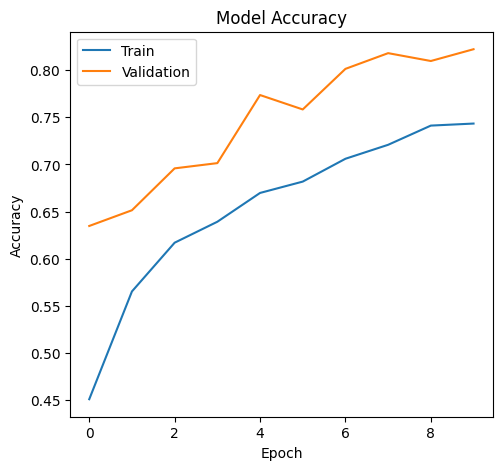

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

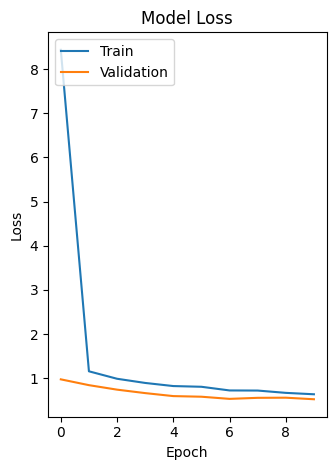

In [15]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Load dataset
df = pd.read_csv("/kaggle/input/analytics-vidya-ripik-ai-hackfest/train/train/train.csv")
images_dir = '/kaggle/input/analytics-vidya-ripik-ai-hackfest/train/train/images'

print("Unique Labels:", df['label'].unique())

# Function to load images
def load_single_image(row):
    img_path = os.path.join(images_dir, row['filename'])
    try:
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img)
        return img_array, row['label']
    except Exception as e:
        print(f"Error loading image {img_path}: {e}")
        return None

# Load all images
image_info = df[['filename', 'label']].to_dict('records')
X, y = [], []

with ThreadPoolExecutor() as executor:
    futures = list(tqdm(executor.map(load_single_image, image_info), total=len(image_info), desc="Loading Images"))
    for result in futures:
        if result:
            img_array, label = result
            X.append(img_array)
            y.append(label)

# Convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.1, random_state=42)
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=20,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow(X_train, y_train, batch_size=64)
val_generator = val_datagen.flow(X_val, y_val, batch_size=64)

# Load base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

# Create full model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')  # adjust class count if needed
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True)
]

# Train the model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

# ✅ Evaluate the model on the validation set
X_val_scaled = X_val / 255.0  # Since val_generator applied rescaling
val_loss, val_accuracy = model.evaluate(X_val_scaled, y_val, verbose=2)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# ✅ Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ✅ Save model
model_save_path = 'saved_model.keras'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

Unique Labels: [2 4 3 5 6 1]


Loading Images: 100%|██████████| 7200/7200 [00:15<00:00, 462.82it/s]


Training set shape: (6480, 224, 224, 3) (6480,)
Validation set shape: (720, 224, 224, 3) (720,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


102/102 ━━━━━━━━━━━━━━━━━━━━ 72s 640ms/step - accuracy: 0.4190 - loss: 2.1491 - val_accuracy: 0.6667 - val_loss: 0.8222
Epoch 2/10
 10/102 ━━━━━━━━━━━━━━━━━━━━ 53s 582ms/step - accuracy: 0.5313 - loss: 1.0822